# 03B - Acoustic + Transcript Bridge Token Fusion Multi-Task SER

Notebook này là bản cập nhật của `03B`: vẫn giữ logic acoustic 06D cũ, nhưng thêm transcript branch để kiểm tra xem linguistic signal có bổ sung cho acoustic signal hay không.

Khác với `03D`, notebook này **không reproduce full paper 2024**. `03D` dùng raw audio + transcript và chạy HuBERT/DeBERTa trực tiếp. `03B` là mô hình đề xuất của project. Để tránh Kaggle bị kẹt ở file `spm.model`, text backbone mặc định là `roberta-base`; nếu môi trường ổn định có thể đổi sang `microsoft/deberta-v3-base`.

```text
06D acoustic features + emotion2vec + frozen transcript encoder + balanced bridge fusion
```

Mục tiêu:

- Giữ đầy đủ nhánh acoustic từ notebook 02: `X_temporal`, `X_spectral`, `X_stats`, `X_e2v`.
- Thêm transcript branch bằng pretrained text model frozen.
- Fusion bằng self-attention, cross-attention và learnable bridge tokens.
- Bật Random Modality Masking để tránh text branch lấn át acoustic branch.
- Có sẵn ablation modes để kiểm tra từng quyết định kiến trúc.

## Sơ đồ tổng thể

```mermaid
flowchart LR
    A["X_temporal<br/>MFCC, delta, prosody, spectral LLD"] --> AT["Temporal CNN/TCN token encoder"]
    B["X_spectral<br/>log-Mel + delta + delta-delta"] --> AS["Spectral CNN token encoder"]
    C["X_stats<br/>mean/std/min/max/median/p10/p90/IQR"] --> AG["Stats MLP token"]
    D["X_e2v<br/>emotion2vec embedding"] --> AE["Emotion2Vec projection token"]
    T["Transcript"] --> TM["Frozen RoBERTa-base<br/>DeBERTaV3 optional"]
    TM --> TT["Text sequence projection"]

    AT --> AK["Acoustic token set"]
    AS --> AK
    AG --> AK
    AE --> AK

    AK --> SA["Acoustic self-attention"]
    TT --> ST["Text self-attention"]

    SA --> CA["Bridge cross-attention<br/>Q_a, K_acoustic, V_text"]
    ST --> CA
    SA --> CT["Bridge cross-attention<br/>Q_t, K_text, V_acoustic"]
    ST --> CT

    CA --> Z["Balanced fusion"]
    CT --> Z
    Z --> H1["Emotion classifier"]
    Z --> H2["VAD regressor"]
```

# 03B Advanced: loss tuning + stronger acoustic branch + training protocol

Notebook này kế thừa toàn bộ pipeline của `03B_CoAttention_Emotion2Vec_Acoustic_MultiTask_5_10Fold.ipynb`, nhưng thêm ba nhóm cải tiến có kiểm soát:

1. **Tune loss multi-task**
   - Giữ chế độ fixed-weight cũ để so sánh.
   - Thêm `LOSS_MODE=uncertainty`, học trọng số loss theo uncertainty thay vì phải dò tay hoàn toàn.
   - Vẫn giữ `CE + CCC + MSE + VAD variance regularization`.

2. **Nâng acoustic branch**
   - Temporal branch dùng multi-scale Conv1D kernels `3/5/7` để học biến thiên ngắn và dài của MFCC/prosody.
   - Thêm Squeeze-and-Excitation cho temporal/spectral CNN để học kênh acoustic nào quan trọng hơn.
   - Thay mean pooling bằng attentive statistics pooling cho audio/text tokens, giữ cả weighted mean và weighted std.

3. **Tối ưu training protocol**
   - Warmup + cosine decay giữ nguyên từ bản 03B.
   - Gradient clipping chuyển thành hyperparameter `MAX_GRAD_NORM`.
   - RMM có warmup, tránh mask acoustic quá sớm vì VAD phụ thuộc nhiều vào audio.
   - Log thêm uncertainty weights nếu dùng `LOSS_MODE=uncertainty`.

## Vì sao chọn các kỹ thuật này?

| Nhóm | Kỹ thuật | Tham khảo | Lý do đưa vào 03B |
|---|---|---|---|
| Multi-task loss | Uncertainty weighting | [Multi-Task Learning Using Uncertainty to Weigh Losses](https://arxiv.org/abs/1705.07115) | Emotion là classification, VAD là regression; hai loss khác scale nên fixed weight dễ lệch task. |
| Multi-task loss | GradNorm | [GradNorm](https://arxiv.org/abs/1711.02257) | Bài báo chỉ ra multi-task cần cân bằng tốc độ học giữa các task; notebook này chưa cài GradNorm full, nhưng dùng làm định hướng so sánh sau. |
| Multi-task loss | PCGrad | [Gradient Surgery for Multi-Task Learning](https://arxiv.org/abs/2001.06782) | Nếu emotion và VAD gradient xung đột, PCGrad là hướng tiếp theo. Notebook này ưu tiên uncertainty vì nhẹ hơn. |
| Acoustic branch | Squeeze-and-Excitation | [Squeeze-and-Excitation Networks](https://arxiv.org/abs/1709.01507) | Acoustic feature nhiều kênh; SE giúp model tự chọn kênh hữu ích thay vì coi mọi kênh ngang nhau. |
| Acoustic pooling | Attentive statistics pooling | [Attentive Statistics Pooling for Deep Speaker Embedding](https://arxiv.org/abs/1803.10963) | Speech emotion/VAD phụ thuộc biến thiên theo thời gian; weighted mean + std tốt hơn mean pooling đơn giản. |
| Acoustic robustness | SpecAugment | [SpecAugment](https://arxiv.org/abs/1904.08779) | Gợi ý ablation sau cho spectral features; bản notebook này chưa bật augmentation mặc định để tránh đổi quá nhiều cùng lúc. |
| Training protocol | Warm restarts / cosine schedule | [SGDR](https://arxiv.org/abs/1608.03983) | Cosine schedule giúp ổn định training; bản 03B đang dùng warmup + cosine decay, có thể thử restart sau. |

## Bảng tham khảo chi tiết

| Bài báo / nguồn | Nhóm kỹ thuật | Đã dùng trong notebook này? | Vị trí trong notebook | Kỳ vọng cải thiện | Rủi ro cần theo dõi |
|---|---|---:|---|---|---|
| [Multi-Task Learning Using Uncertainty to Weigh Losses](https://arxiv.org/abs/1705.07115) | Multi-task loss balancing | Có | `MultiTaskLossBalancer`, `LOSS_MODE=uncertainty` | Giảm việc emotion CE áp đảo VAD regression; tự học trọng số loss theo độ khó task. | Nếu uncertainty học lệch, một task có thể bị giảm trọng số quá mạnh. Cần xem `loss_w_ce`, `loss_w_ccc`, `loss_w_mse` trong history. |
| [GradNorm: Gradient Normalization for Adaptive Loss Balancing](https://arxiv.org/abs/1711.02257) | Multi-task gradient balancing | Chưa cài full | Định hướng sau ablation | Cân bằng tốc độ học giữa emotion và VAD bằng gradient norm. | Cài đặt phức tạp hơn vì phải tách backward từng task. |
| [Gradient Surgery for Multi-Task Learning](https://arxiv.org/abs/2001.06782) | Conflict-aware multi-task optimization | Chưa cài full | Định hướng sau ablation | Nếu emotion và VAD gradient xung đột, PCGrad có thể giảm ảnh hưởng tiêu cực giữa task. | Tốn thêm compute và code phức tạp hơn. |
| [Squeeze-and-Excitation Networks](https://arxiv.org/abs/1709.01507) | Channel attention | Có | `SEBlock1D`, `SEBlock2D`, `USE_SE_BLOCK=1` | Acoustic có nhiều kênh MFCC/log-Mel/prosody; SE giúp model tự tăng/giảm kênh quan trọng. | Nếu data ít, SE có thể overfit nhẹ; cần theo dõi gap train/val. |
| [Attentive Statistics Pooling for Deep Speaker Embedding](https://arxiv.org/abs/1803.10963) | Attention pooling cho speech | Có | `TokenAttentiveStatisticsPooling`, `USE_ATTENTIVE_POOLING=1` | Speech emotion phụ thuộc đoạn nổi bật, không nên chỉ mean pooling. Weighted mean + std giữ thông tin biến thiên. | Attention có thể tập trung sai nếu branch acoustic chưa học ổn. |
| [SpecAugment](https://arxiv.org/abs/1904.08779) | Data augmentation cho spectral feature | Chưa bật mặc định | Hướng ablation sau | Tăng robustness cho log-Mel/spectral branch. | Có thể làm giảm điểm nếu augmentation quá mạnh với IEMOCAP nhỏ. |
| [SGDR: Stochastic Gradient Descent with Warm Restarts](https://arxiv.org/abs/1608.03983) | Training schedule | Một phần | Warmup + cosine schedule hiện tại | Giúp learning rate giảm mềm, training ổn định hơn fixed LR. | Warm restart chưa bật vì cần ablation riêng. |
| [Attention Is All You Need](https://arxiv.org/abs/1706.03762) | Self-attention / cross-attention nền tảng | Có | `TransformerEncoderLayer`, `MultiheadAttention` bridge | Cho phép token acoustic và text tương tác linh hoạt hơn concat vector. | Nếu bridge quá mạnh, text có thể lấn VAD; vì vậy VAD head đang dùng `acoustic_heavy`. |

## Giải thích từng kỹ thuật được thêm

### 1. Uncertainty weighting cho multi-task loss

Vấn đề của 03B là có hai loại task khác nhau:

| Task | Output | Loss chính | Metric chính |
|---|---|---|---|
| Emotion classification | 4 lớp emotion | Cross-entropy | WA, UAR, Macro-F1 |
| VAD regression | valence, arousal, dominance | CCC + MSE | CCC, MAE |

Nếu dùng loss cố định:

```text
L = w_ce * L_ce + w_ccc * L_ccc + w_mse * L_mse
```

ta phải tự dò `w_ce`, `w_ccc`, `w_mse`. Uncertainty weighting học các trọng số này qua tham số `log_vars`:

```text
L_total = sum(exp(-s_i) * L_i + s_i)
```

Trong notebook:

```text
LOSS_MODE=uncertainty
```

sẽ bật `MultiTaskLossBalancer`. Trong history sẽ có:

```text
loss_w_ce
loss_w_ccc
loss_w_mse
```

để xem model đang ưu tiên task nào.

### 2. Multi-scale Temporal Conv1D

Acoustic temporal features không chỉ có một loại biến thiên. Pitch/energy có thể thay đổi rất nhanh, còn prosody/rhythm thay đổi chậm hơn. Vì vậy temporal branch dùng ba kernel song song:

```text
kernel 3: biến thiên ngắn
kernel 5: biến thiên trung bình
kernel 7: biến thiên dài hơn
```

Sau đó concat và project lại về `hidden_dim`.

| Flag | Ý nghĩa |
|---|---|
| `ACOUSTIC_BRANCH_MODE=advanced` | bật acoustic branch nâng cấp |
| `USE_MULTISCALE_TEMPORAL=1` | bật Conv1D đa kernel |

### 3. Squeeze-and-Excitation cho acoustic channels

SE block học trọng số theo kênh:

```text
channel_weight = sigmoid(MLP(global_average_pool(x)))
x_out = x * channel_weight
```

Với acoustic branch, điều này giúp model học được kênh nào quan trọng hơn, ví dụ MFCC, energy, pitch, log-Mel region, hoặc spectral pattern.

| Block | Vai trò |
|---|---|
| `SEBlock1D` | dùng cho temporal Conv1D |
| `SEBlock2D` | dùng cho spectral Conv2D |
| `USE_SE_BLOCK=1` | bật/tắt SE |

### 4. Attentive Statistics Pooling

Bản cũ lấy mean pooling token:

```text
audio_pool = mean(audio_tokens)
```

Bản advanced dùng attention để học token nào quan trọng hơn:

```text
alpha_t = softmax(score(h_t))
mean = sum(alpha_t * h_t)
std = sqrt(sum(alpha_t * (h_t - mean)^2))
pool = MLP([mean, std])
```

Lý do: với speech emotion, một đoạn ngắn có thể chứa tín hiệu cảm xúc rất mạnh. Mean pooling dễ làm loãng tín hiệu đó.

### 5. RMM warmup và acoustic-aware VAD

VAD, đặc biệt arousal và dominance, phụ thuộc nhiều vào audio/prosody. Vì vậy bản advanced giữ nguyên ý tưởng RMM nhưng không mask modality ngay từ đầu:

```text
RMM_WARMUP_EPOCHS=8
```

Sau warmup, RMM chủ yếu mask text:

```text
RMM_TEXT_PROB=0.90
```

Mục tiêu là ép model không phụ thuộc quá mức vào transcript, đồng thời không phá acoustic branch quá sớm.

### 6. Training protocol cần theo dõi

| Tín hiệu log | Cách đọc |
|---|---|
| `val_UAR` tăng nhưng `val_CCC` giảm | emotion đang thắng VAD, cần tăng ưu tiên VAD hoặc giảm text dominance |
| `VAD_pred_std_mean` rất nhỏ so với `VAD_true_std_mean` | VAD collapse, cần kiểm scale/loss |
| `loss_w_ce` quá lớn, `loss_w_ccc` quá nhỏ | uncertainty đang ưu tiên classification quá nhiều |
| train loss giảm nhưng val CCC giảm | overfit acoustic/fusion, cần dropout/weight decay/early stopping |
| CCC dominance thấp hơn valence/arousal | dominance cần acoustic/prosody mạnh hơn, có thể thử `VAD_REPRESENTATION=acoustic_only` |

## Cấu hình mặc định của bản advanced

```text
LOSS_MODE=uncertainty
ACOUSTIC_BRANCH_MODE=advanced
USE_ATTENTIVE_POOLING=1
USE_SE_BLOCK=1
USE_MULTISCALE_TEMPORAL=1
MAX_GRAD_NORM=1.0
RMM_WARMUP_EPOCHS=8
RMM_START=0.15
RMM_TEXT_PROB=0.90
```

Gợi ý chạy so sánh công bằng:

```text
1. Chạy notebook 03B cũ lấy baseline.
2. Chạy notebook này cùng split 5-fold.
3. So sánh UAR, Macro-F1, CCC_mean, CCC_valence/arousal/dominance, MAE.
4. Nếu CCC tăng nhưng UAR giảm nhẹ, cân nhắc chỉnh PRIMARY_UAR_WEIGHT / PRIMARY_CCC_WEIGHT.
```

## Bảng bằng chứng học thuật cho từng kỹ thuật

| Kỹ thuật | Paper / nguồn | Ý tưởng dùng trong notebook | Vì sao dùng trong 03B |
|---|---|---|---|
| Self-attention / Multi-head attention | [Attention Is All You Need](https://arxiv.org/abs/1706.03762) | Học quan hệ giữa các token bằng \(Q,K,V\). | Acoustic và text đều là chuỗi tín hiệu, cần attention để chọn vùng quan trọng. |
| Bridge tokens / bottleneck fusion | [Attention Bottlenecks for Multimodal Fusion](https://arxiv.org/abs/2107.00135) | Ép thông tin giữa modality đi qua một số token trung gian. | Giảm nhiễu khi fusion nhiều modality, tránh nối thẳng vector quá thô. |
| Speech + transcript bridge fusion | [A Multi-Task, Multi-Modal Approach for Predicting Categorical and Dimensional Emotions](https://arxiv.org/abs/2401.00536) | Self-attention từng modality, dual cross-attention, bridge tokens, CE+CCC multi-task loss. | Là nguồn cảm hứng chính cho transcript + bridge fusion trong 03B. |
| emotion2vec | [emotion2vec: Self-Supervised Pre-Training for Speech Emotion Representation](https://arxiv.org/abs/2312.15185) | Dùng embedding cảm xúc pretrained làm một acoustic token. | Bổ sung representation cảm xúc học từ dữ liệu lớn, hỗ trợ nhánh 06D handcrafted. |
| Temporal emotional modeling | [Temporal Modeling Matters / TIM-Net](https://arxiv.org/abs/2211.08233) | Dùng temporal branch để học biến thiên cảm xúc theo thời gian. | 06D cũ có nhiều feature nhưng cần mô hình temporal mạnh hơn thay vì chỉ thống kê. |
| RoBERTa / DeBERTaV3 | [RoBERTa](https://arxiv.org/abs/1907.11692), [DeBERTaV3](https://arxiv.org/abs/2111.09543) | Frozen transcript encoder, lấy sequence hidden states. | Có linguistic context đủ mạnh nhưng không fine-tune nặng. Mặc định dùng `roberta-base` để tránh Kaggle kẹt `spm.model`. |
| Multi-task learning | [Attention-Augmented End-to-End Multi-Task Learning for Emotion Prediction from Speech](https://arxiv.org/abs/1903.12424) | Emotion classification và VAD regression học chung. | Các nhãn categorical và dimensional có thể regularize nhau. |

## Giải thích các thuật toán chính

> Lưu ý: công thức được tách khỏi bảng để tránh Kaggle/Jupyter render lỗi LaTeX trong markdown table.

| Thuật toán | Vai trò trong 03B | Giải thích ngắn |
|---|---|---|
| Scaled dot-product attention | Nền tảng của self-attention và cross-attention | Query hỏi "cần nhìn đâu", key giúp tính độ liên quan, value là thông tin được trộn theo trọng số. |
| Multi-head attention | Dùng trong Transformer/self-attention và bridge cross-attention | Nhiều head giúp học nhiều kiểu quan hệ khác nhau giữa acoustic/text tokens. |
| Self-attention | Xử lý riêng acoustic tokens và text tokens trước khi fusion | Acoustic self-attention chọn vùng âm học quan trọng; text self-attention chọn token/ngữ cảnh quan trọng. |
| Cross-attention | Bridge token kéo thông tin từ acoustic/text | Bridge token học cách lấy thông tin từ từng modality theo hướng có kiểm soát. |
| Bridge tokens | Token trung gian giữa acoustic và text | Token học được, đóng vai trò "cầu nối" giữa acoustic và text. |
| Gated fusion | Cân bằng acoustic/text trong vector fusion | Gate học mức độ tin acoustic/text ở từng chiều embedding. |
| Random Modality Masking | Regularization cho multimodal learning | Trong train, thỉnh thoảng che text hoặc acoustic để model không phụ thuộc quá mức vào một modality. |
| CCC loss | Loss/metric cho valence, arousal, dominance | CCC quan tâm cả tương quan và độ khớp tuyệt đối giữa dự đoán và nhãn. |

### Công thức

**Scaled dot-product attention**
$$
\operatorname{Attention}(Q,K,V)
=
\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

**Multi-head attention**
$$
\operatorname{head}_i
=
\operatorname{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

$$
\operatorname{MHA}(Q,K,V)
=
\operatorname{Concat}(\operatorname{head}_1,\ldots,\operatorname{head}_h)W^O
$$

**Self-attention**
$$
Q = XW^Q,\quad K = XW^K,\quad V = XW^V
$$
Trong self-attention, \(Q,K,V\) cùng được tạo từ một modality, ví dụ acoustic tokens hoặc text tokens.

**Cross-attention**
$$
Q = Z_{\mathrm{bridge}}W^Q,\quad
K = X_{\mathrm{modality}}W^K,\quad
V = X_{\mathrm{modality}}W^V
$$
Trong 03B, bridge tokens đóng vai trò query để lấy thông tin từ acoustic/text token set.

**Bridge tokens**
$$
Q_a, Q_t \in \mathbb{R}^{L \times d}
$$
Trong đó \(L\) là số bridge tokens và \(d\) là hidden dimension.

**Gated fusion**
$$
g = \sigma(W_g[z_a;z_t] + b_g)
$$

$$
z = z_{\mathrm{bridge}} + g \odot z_a + (1-g)\odot z_t
$$

**Random Modality Masking**
$$
m \sim \operatorname{Bernoulli}(p)
$$
Nếu mask text, text token được đặt về 0; nếu mask acoustic, acoustic token được đặt về 0.

**Concordance Correlation Coefficient**
$$
\operatorname{CCC}(\hat{y},y)
=
\frac{2\,\operatorname{Cov}(\hat{y},y)}
{\sigma_{\hat{y}}^2+\sigma_y^2+(\mu_{\hat{y}}-\mu_y)^2}
$$

Trong training, CCC loss thường được viết là:
$$
\mathcal{L}_{CCC}=1-\operatorname{CCC}(\hat{y},y)
$$

## Các chế độ ablation có sẵn

Notebook mặc định chạy:

```text
FUSION_MODE=acoustic_text_bridge_rmm
```

Các mode khác để so sánh:

| Mode | Ý nghĩa | Mục đích |
|---|---|---|
| `acoustic_only` | Chỉ dùng `X_temporal + X_spectral + X_stats + X_e2v` | Baseline giữ logic 03B cũ |
| `text_only` | Chỉ dùng transcript branch | Xem text mạnh tới đâu |
| `acoustic_text_concat` | Acoustic + text nối vector đơn giản | Baseline fusion dễ nhất |
| `acoustic_text_bridge` | Acoustic + text bằng dual bridge cross-attention | Kiểm tra bridge tokens |
| `acoustic_text_bridge_rmm` | Bridge fusion + Random Modality Masking | Mode đề xuất mặc định |

Nếu `acoustic_text_bridge_rmm` tốt hơn `acoustic_text_concat`, ta có bằng chứng rằng bridge/RMM có ích hơn nối vector thẳng.

## Sơ đồ riêng cho transcript branch và emotion2vec token

### Transcript branch

```mermaid
flowchart LR
    TXT["Raw transcript"] --> TOK["Tokenizer<br/>RoBERTa BPE vocabulary"]
    TOK --> IDS["input_ids + attention_mask"]
    IDS --> DB["Frozen RoBERTa-base<br/>DeBERTaV3 optional"]
    DB --> HS["Sequence hidden states<br/>B x L_text x d_text"]
    HS --> PROJ["Linear projection<br/>d_text -> d_model"]
    PROJ --> TEXTTOK["Text tokens<br/>B x L_text x d_model"]
```

Text encoder được frozen mặc định (`TEXT_LR=0.0`) để tránh train nặng và để text branch không overfit quá nhanh trên IEMOCAP. Notebook mặc định dùng `roberta-base` vì RoBERTa tải `vocab.json/merges.txt`, không cần `spm.model`. Nếu muốn thử lại DeBERTaV3, set:

```text
TEXT_MODEL_NAME=microsoft/deberta-v3-base
```

### emotion2vec token

```mermaid
flowchart LR
    WAV["Audio utterance"] --> E2V["emotion2vec pretrained encoder<br/>đã trích ở notebook 02"]
    E2V --> VEC["X_e2v: B x 768"]
    VEC --> PROJ["LayerNorm + MLP projection"]
    PROJ --> TOK["emotion2vec token<br/>B x 1 x d_model"]
```

Trong 03B, `emotion2vec` không được fine-tune trực tiếp. Nó đóng vai trò token cảm xúc pretrained để hướng dẫn fusion với acoustic handcrafted features.

## Random Modality Masking là gì?

Random Modality Masking (RMM) là kỹ thuật che ngẫu nhiên một modality trong lúc train.

Với xác suất \(p(e)\) tại epoch \(e\):

$$
p(e)=p_0 \cdot \frac{1+\cos(\pi \cdot e/E)}{2}
$$

Trong notebook:

- \(p_0 = 0.65\)
- xác suất mask text: `0.65`
- xác suất mask acoustic: `0.35`
- \(p(e)\) giảm dần theo epoch

Lý do mask text nhiều hơn acoustic: transcript thường dễ học hơn và có thể làm model bỏ qua tín hiệu speech/acoustic. RMM ép model phải học cả acoustic và transcript, từ đó fusion cân bằng hơn.

In [1]:
import os
import sys
import json
import math
import time
import random
import zipfile
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    plt = None
    sns = None

pd.set_option("display.max_columns", 140)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("CUDA devices:", torch.cuda.device_count())

DEVICE: cuda
CUDA devices: 2


In [2]:
INSTALL_DEPS = os.getenv("INSTALL_DEPS", "1") == "1"
if INSTALL_DEPS:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "-U",
        "transformers==4.51.3",
        "tokenizers==0.21.1",
        "huggingface_hub==0.30.2",
        "sentencepiece",
        "accelerate",
        "safetensors",
    ])

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 232.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.4/481.4 kB 398.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 416.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 396.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 393.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.30.2 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.30.2 which is incompatible.


In [3]:
LOCAL_PROJECT = Path(r"D:\UTE\Speech Programming\Speech Project")

def unique_existing(paths):
    out, seen = [], set()
    for item in paths:
        if not item:
            continue
        p = Path(item)
        key = str(p)
        if key not in seen and p.exists():
            out.append(p)
            seen.add(key)
    return out

def search_roots():
    return unique_existing([
        Path(os.getenv("FEATURE_ROOT", "")),
        Path(os.getenv("IEMOCAP_DATA_DIR", "")),
        Path(os.getenv("DATA_DIR", "")),
        Path.cwd(),
        Path("/kaggle/working"),
        Path("/kaggle/input"),
        LOCAL_PROJECT,
        LOCAL_PROJECT / "06_w2v_based_models",
        LOCAL_PROJECT / "06_w2v_based_models" / "02_IEMOCAP Feature Extraction Emotion2Vec Acoustic" / "output",
    ])

def find_named_file(filename, required=True):
    direct = Path(filename)
    if direct.exists():
        return direct.resolve()
    for root in search_roots():
        try:
            for p in root.rglob(filename):
                if p.is_file():
                    return p.resolve()
        except Exception:
            continue
    if required:
        roots = "\n".join(f"- {p}" for p in search_roots())
        raise FileNotFoundError(f"Không tìm thấy `{filename}`. Đã quét:\n{roots}")
    return None

def maybe_extract_zips():
    extract_dir = Path("extracted_03b_inputs")
    extract_dir.mkdir(parents=True, exist_ok=True)
    for root in search_roots():
        try:
            zips = list(root.rglob("*.zip"))
        except Exception:
            continue
        for z in zips:
            lname = z.name.lower()
            if not any(k in lname for k in ["output", "03b", "iemocap", "feature", "roberta", "pretrained", "huggingface", "hf-model"]):
                continue
            target = extract_dir / z.stem
            marker = target / ".extracted"
            if marker.exists():
                continue
            try:
                target.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(z, "r") as zipf:
                    zipf.extractall(target)
                marker.write_text("ok", encoding="utf-8")
                print("Extracted:", z)
            except Exception as exc:
                print("Không giải nén được:", z, exc)

maybe_extract_zips()

In [4]:
RUN_MODE = os.getenv("RUN_MODE", "full").strip().lower()
IS_TUNE_MODE = RUN_MODE != "full"

TEXT_MODEL_NAME = os.getenv("TEXT_MODEL_NAME", "roberta-base")
TEXT_MODEL_PATH = os.getenv("TEXT_MODEL_PATH", "").strip()
ALLOW_HF_DOWNLOAD = os.getenv("ALLOW_HF_DOWNLOAD", "0") == "1"
MAX_TEXT_LENGTH = int(os.getenv("MAX_TEXT_LENGTH", "96"))
FUSION_MODE = os.getenv("FUSION_MODE", "acoustic_text_bridge_rmm").strip().lower()
VALID_FUSION_MODES = {
    "acoustic_only",
    "text_only",
    "acoustic_text_concat",
    "acoustic_text_bridge",
    "acoustic_text_bridge_rmm",
}
if FUSION_MODE not in VALID_FUSION_MODES:
    raise ValueError(f"FUSION_MODE phải thuộc {sorted(VALID_FUSION_MODES)}, hiện tại: {FUSION_MODE}")

RUN_PROTOCOLS = [x.strip() for x in os.getenv(
    "RUN_PROTOCOLS",
    "5fold_session"
).split(",") if x.strip()]
MAX_FOLDS = int(os.getenv("MAX_FOLDS", "0" if not IS_TUNE_MODE else "1"))

EPOCHS = int(os.getenv("EPOCHS", "90" if not IS_TUNE_MODE else "8"))
PATIENCE = int(os.getenv("PATIENCE", "14" if not IS_TUNE_MODE else "3"))
MIN_DELTA = float(os.getenv("MIN_DELTA", "0.001"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "12"))
GRAD_ACCUM = int(os.getenv("GRAD_ACCUM", "1"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "0"))

HIDDEN_DIM = int(os.getenv("HIDDEN_DIM", "256"))
NUM_HEADS = int(os.getenv("NUM_HEADS", "8"))
BRIDGE_TOKENS = int(os.getenv("BRIDGE_TOKENS", "16"))
DROPOUT = float(os.getenv("DROPOUT", "0.30"))
LR = float(os.getenv("LR", "5e-4"))
TEXT_LR = float(os.getenv("TEXT_LR", "0.0"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "2e-4"))
WARMUP_RATIO = float(os.getenv("WARMUP_RATIO", "0.08"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.05"))
USE_CLASS_WEIGHTS = os.getenv("USE_CLASS_WEIGHTS", "1") == "1"
USE_BALANCED_SAMPLER = os.getenv("USE_BALANCED_SAMPLER", "0") == "1"
USE_AMP = os.getenv("USE_AMP", "1") == "1"

USE_RMM = FUSION_MODE.endswith("_rmm")
RMM_START = float(os.getenv("RMM_START", "0.15"))
RMM_TEXT_PROB = float(os.getenv("RMM_TEXT_PROB", "0.90"))
RMM_MIN_THRESHOLD = float(os.getenv("RMM_MIN_THRESHOLD", "0.05"))
RMM_WARMUP_EPOCHS = int(os.getenv("RMM_WARMUP_EPOCHS", "8"))

CE_WEIGHT = float(os.getenv("CE_WEIGHT", "0.35"))
CCC_WEIGHT = float(os.getenv("CCC_WEIGHT", "0.45"))
MSE_WEIGHT = float(os.getenv("MSE_WEIGHT", "0.20"))
VAD_VAR_WEIGHT = float(os.getenv("VAD_VAR_WEIGHT", "0.05"))
PRIMARY_UAR_WEIGHT = float(os.getenv("PRIMARY_UAR_WEIGHT", "0.40"))
PRIMARY_CCC_WEIGHT = float(os.getenv("PRIMARY_CCC_WEIGHT", "0.60"))
VAD_REPRESENTATION = os.getenv("VAD_REPRESENTATION", "acoustic_heavy").strip().lower()
LOSS_MODE = os.getenv("LOSS_MODE", "uncertainty").strip().lower()
ACOUSTIC_BRANCH_MODE = os.getenv("ACOUSTIC_BRANCH_MODE", "advanced").strip().lower()
USE_ATTENTIVE_POOLING = os.getenv("USE_ATTENTIVE_POOLING", "1") == "1"
USE_SE_BLOCK = os.getenv("USE_SE_BLOCK", "1") == "1"
USE_MULTISCALE_TEMPORAL = os.getenv("USE_MULTISCALE_TEMPORAL", "1") == "1"
MAX_GRAD_NORM = float(os.getenv("MAX_GRAD_NORM", "1.0"))
VAD_RAW_MIN = float(os.getenv("VAD_RAW_MIN", "1.0"))
VAD_RAW_MAX = float(os.getenv("VAD_RAW_MAX", "5.0"))

SEED = int(os.getenv("SEED", "42"))
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "output_03b_advanced_loss_acoustic_protocol")).resolve()
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
FUSION_DIR = OUTPUT_DIR / "fusion_features"
for p in [MODEL_DIR, REPORT_DIR, FIGURE_DIR, FUSION_DIR]:
    p.mkdir(parents=True, exist_ok=True)

LIVE_LOG_PATH = REPORT_DIR / "03B_live_training_log.txt"
LOG_EVERY_STEPS = int(os.getenv("LOG_EVERY_STEPS", "25"))
SCALER_CHUNK_SIZE = int(os.getenv("SCALER_CHUNK_SIZE", "128"))

def live_log(message):
    stamp = time.strftime("%Y-%m-%d %H:%M:%S")
    text = f"[{stamp}] {message}"
    print(text, flush=True)
    with LIVE_LOG_PATH.open("a", encoding="utf-8") as f:
        f.write(text + "\n")

def _norm_model_name(value):
    return str(value).lower().replace("\\", "/").replace("_", "-").replace(".", "-")

def _looks_like_hf_text_model(path):
    path = Path(path)
    if not path.is_dir():
        return False
    has_config = (path / "config.json").exists()
    has_weight = any((path / name).exists() for name in ["model.safetensors", "pytorch_model.bin"])
    has_tokenizer = any((path / name).exists() for name in [
        "tokenizer.json",
        "vocab.json",
        "vocab.txt",
        "sentencepiece.bpe.model",
        "spm.model",
        "merges.txt",
    ])
    return has_config and has_weight and has_tokenizer

def find_local_text_model(model_name):
    if TEXT_MODEL_PATH:
        p = Path(TEXT_MODEL_PATH)
        if _looks_like_hf_text_model(p):
            return p.resolve()
        raise FileNotFoundError(
            f"TEXT_MODEL_PATH đã được set nhưng không giống folder Hugging Face hợp lệ: {p}. "
            "Folder cần có config.json, weight file và tokenizer files."
        )

    wanted = _norm_model_name(model_name).split("/")[-1]
    candidates = []
    for root in search_roots():
        try:
            for cfg in root.rglob("config.json"):
                folder = cfg.parent
                if _looks_like_hf_text_model(folder):
                    normalized = _norm_model_name(folder)
                    score = 0 if wanted in normalized else 1
                    candidates.append((score, len(folder.parts), str(folder).lower(), folder.resolve()))
        except Exception:
            continue
    if candidates:
        return sorted(candidates)[0][-1]
    return None

TEXT_MODEL_SOURCE = find_local_text_model(TEXT_MODEL_NAME)
if TEXT_MODEL_SOURCE is None:
    if not ALLOW_HF_DOWNLOAD:
        roots = "\n".join(f"- {p}" for p in search_roots())
        raise FileNotFoundError(
            "Không tìm thấy pretrained text model local cho 03B. Để tránh Kaggle treo ở bước tải 0.00/499M, "
            "notebook đang chặn download online mặc định.\n\n"
            "Cách chạy ổn định nhất: upload Hugging Face model `roberta-base` thành Kaggle Dataset, rồi set "
            "TEXT_MODEL_PATH tới folder đó, hoặc để notebook tự quét /kaggle/input.\n\n"
            "Nếu vẫn muốn tải online, set ALLOW_HF_DOWNLOAD=1.\n\n"
            f"Notebook đã quét:\n{roots}"
        )
    TEXT_MODEL_SOURCE = TEXT_MODEL_NAME
else:
    TEXT_MODEL_SOURCE = str(TEXT_MODEL_SOURCE)
live_log(f"TEXT_MODEL_SOURCE={TEXT_MODEL_SOURCE}")
live_log(f"ALLOW_HF_DOWNLOAD={ALLOW_HF_DOWNLOAD}")

config = {
    "TEXT_MODEL_NAME": TEXT_MODEL_NAME,
    "TEXT_MODEL_PATH": TEXT_MODEL_PATH,
    "TEXT_MODEL_SOURCE": str(TEXT_MODEL_SOURCE),
    "ALLOW_HF_DOWNLOAD": ALLOW_HF_DOWNLOAD,
    "FUSION_MODE": FUSION_MODE,
    "RUN_PROTOCOLS": RUN_PROTOCOLS,
    "MAX_FOLDS": MAX_FOLDS,
    "EPOCHS": EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "HIDDEN_DIM": HIDDEN_DIM,
    "NUM_HEADS": NUM_HEADS,
    "BRIDGE_TOKENS": BRIDGE_TOKENS,
    "LR": LR,
    "TEXT_LR": TEXT_LR,
    "USE_RMM": USE_RMM,
    "RMM_START": RMM_START,
    "RMM_TEXT_PROB": RMM_TEXT_PROB,
    "RMM_WARMUP_EPOCHS": RMM_WARMUP_EPOCHS,
    "USE_BALANCED_SAMPLER": USE_BALANCED_SAMPLER,
    "CE_WEIGHT": CE_WEIGHT,
    "CCC_WEIGHT": CCC_WEIGHT,
    "MSE_WEIGHT": MSE_WEIGHT,
    "VAD_VAR_WEIGHT": VAD_VAR_WEIGHT,
    "PRIMARY_UAR_WEIGHT": PRIMARY_UAR_WEIGHT,
    "PRIMARY_CCC_WEIGHT": PRIMARY_CCC_WEIGHT,
    "VAD_REPRESENTATION": VAD_REPRESENTATION,
    "LOSS_MODE": LOSS_MODE,
    "ACOUSTIC_BRANCH_MODE": ACOUSTIC_BRANCH_MODE,
    "USE_ATTENTIVE_POOLING": USE_ATTENTIVE_POOLING,
    "USE_SE_BLOCK": USE_SE_BLOCK,
    "USE_MULTISCALE_TEMPORAL": USE_MULTISCALE_TEMPORAL,
    "MAX_GRAD_NORM": MAX_GRAD_NORM,
    "VAD_RAW_MIN": VAD_RAW_MIN,
    "VAD_RAW_MAX": VAD_RAW_MAX,
    "LOG_EVERY_STEPS": LOG_EVERY_STEPS,
    "SCALER_CHUNK_SIZE": SCALER_CHUNK_SIZE,
    "OUTPUT_DIR": str(OUTPUT_DIR),
}
print(json.dumps(config, indent=2, ensure_ascii=False))

[2026-07-14 11:20:57] TEXT_MODEL_SOURCE=/kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle
[2026-07-14 11:20:57] ALLOW_HF_DOWNLOAD=False
{
  "TEXT_MODEL_NAME": "roberta-base",
  "TEXT_MODEL_PATH": "",
  "TEXT_MODEL_SOURCE": "/kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle",
  "ALLOW_HF_DOWNLOAD": false,
  "FUSION_MODE": "acoustic_text_bridge_rmm",
  "RUN_PROTOCOLS": [
    "5fold_session"
  ],
  "MAX_FOLDS": 0,
  "EPOCHS": 90,
  "BATCH_SIZE": 12,
  "HIDDEN_DIM": 256,
  "NUM_HEADS": 8,
  "BRIDGE_TOKENS": 16,
  "LR": 0.0005,
  "TEXT_LR": 0.0,
  "USE_RMM": true,
  "RMM_START": 0.15,
  "RMM_TEXT_PROB": 0.9,
  "RMM_WARMUP_EPOCHS": 8,
  "USE_BALANCED_SAMPLER": false,
  "CE_WEIGHT": 0.35,
  "CCC_WEIGHT": 0.45,
  "MSE_WEIGHT": 0.2,
  "VAD_VAR_WEIGHT": 0.05,
  "PRIMARY_UAR_WEIGHT": 0.4,
  "PRIMARY_CCC_WEIGHT": 0.6,
  "VAD_REPRESENTATION": "acoustic_heavy",
  "LOSS_MODE": "uncertainty",
  "ACOUSTIC_BRANCH_MODE": "advanced",
  "USE_ATTENTIVE_POOLING": true,
  "USE_SE_BLOCK":

In [5]:
FEATURE_CACHE_PATH = find_named_file("iemocap_full_06d_multibranch_cache.npz")
print("FEATURE_CACHE_PATH:", FEATURE_CACHE_PATH)

cache = np.load(FEATURE_CACHE_PATH, allow_pickle=True)
sample_ids = cache["train_sample_id"].astype(str)
utterance_ids = cache["utterance_ids"].astype(str)
labels_cache = cache["labels"].astype(np.int64)
vad_cache = cache["vad"].astype(np.float32)
X_temporal = cache["X_temporal"].astype(np.float32)
X_spectral = cache["X_spectral"].astype(np.float32)
X_stats = cache["X_stats"].astype(np.float32)
X_e2v = cache["X_e2v"].astype(np.float32)

feature_index = {sid: i for i, sid in enumerate(sample_ids)}
print("Cache loaded:")
print("X_temporal:", X_temporal.shape)
print("X_spectral:", X_spectral.shape)
print("X_stats:", X_stats.shape)
print("X_e2v:", X_e2v.shape)
print("VAD:", vad_cache.shape)
print("VAD raw min/max/mean/std:", vad_cache.min(axis=0), vad_cache.max(axis=0), vad_cache.mean(axis=0), vad_cache.std(axis=0))
vad_norm_preview = np.clip((vad_cache - VAD_RAW_MIN) / max(VAD_RAW_MAX - VAD_RAW_MIN, 1e-6), 0.0, 1.0).astype(np.float32)
print("VAD normalized min/max/mean/std:", vad_norm_preview.min(axis=0), vad_norm_preview.max(axis=0), vad_norm_preview.mean(axis=0), vad_norm_preview.std(axis=0))

FEATURE_CACHE_PATH: /kaggle/input/datasets/quanghuy225/output02/output/features/iemocap_full_06d_multibranch_cache.npz
Cache loaded:
X_temporal: (5531, 135, 601)
X_spectral: (5531, 3, 96, 601)
X_stats: (5531, 1224)
X_e2v: (5531, 768)
VAD: (5531, 3)
VAD raw min/max/mean/std: [1.  1.  0.5] [5.5 5.  5. ] [2.9067519 3.078106  3.1709456] [0.95030177 0.753094   0.82302463]
VAD normalized min/max/mean/std: [0. 0. 0.] [1. 1. 1.] [0.4766203 0.5195261 0.5427818] [0.23740484 0.18827341 0.20562169]


In [6]:
SPLIT_FILES = {
    "5fold_session": "iemocap_5fold_session_long.csv",
    "10fold_speaker": "iemocap_10fold_speaker_long.csv",
}

split_tables = {}
for protocol in RUN_PROTOCOLS:
    path = find_named_file(SPLIT_FILES[protocol])
    df = pd.read_csv(path)
    df = df[df["train_sample_id"].astype(str).isin(feature_index)].copy()
    df["train_sample_id"] = df["train_sample_id"].astype(str)
    df["utterance_id"] = df["utterance_id"].astype(str)
    df["emotion_id"] = df["emotion_id"].astype(int)
    df["transcript"] = df["transcript"].fillna("").astype(str)
    split_tables[protocol] = df
    print(protocol, path, df.shape)
    display(df.groupby(["fold", "split"]).size().unstack(fill_value=0).head())

5fold_session /kaggle/input/datasets/quanghuy225/output01/output/splits/iemocap_5fold_session_long.csv (27655, 35)


split,test,train,val
fold,,,
fold_1_test_Ses01_val_Ses02,1085,3423,1023
fold_2_test_Ses02_val_Ses03,1023,3357,1151
fold_3_test_Ses03_val_Ses04,1151,3349,1031
fold_4_test_Ses04_val_Ses05,1031,3259,1241
fold_5_test_Ses05_val_Ses01,1241,3205,1085


In [7]:
live_log(f"Loading tokenizer from: {TEXT_MODEL_SOURCE}")
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_SOURCE, local_files_only=not ALLOW_HF_DOWNLOAD)
live_log(f"Loaded tokenizer from: {TEXT_MODEL_SOURCE}")

[2026-07-14 11:21:23] Loading tokenizer from: /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle
[2026-07-14 11:21:23] Loaded tokenizer from: /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle


In [8]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def fold_sort_key(name):
    import re
    m = re.search(r"fold_(\d+)", str(name))
    return int(m.group(1)) if m else str(name)

def vad_to_model_scale(values):
    values = np.asarray(values, dtype=np.float32)
    scaled = (values - VAD_RAW_MIN) / max(VAD_RAW_MAX - VAD_RAW_MIN, 1e-6)
    return np.clip(scaled, 0.0, 1.0).astype(np.float32)

def vad_from_model_scale(values):
    values = np.asarray(values, dtype=np.float32)
    return values * (VAD_RAW_MAX - VAD_RAW_MIN) + VAD_RAW_MIN

def concordance_ccc_np(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    out = []
    for j in range(y_true.shape[1]):
        x, y = y_pred[:, j], y_true[:, j]
        mx, my = x.mean(), y.mean()
        vx, vy = x.var(), y.var()
        cov = ((x - mx) * (y - my)).mean()
        out.append(float((2 * cov) / (vx + vy + (mx - my) ** 2 + eps)))
    return np.asarray(out, dtype=np.float32)

def concordance_ccc_torch(pred, target, eps=1e-8):
    pred_mean = pred.mean(dim=0)
    target_mean = target.mean(dim=0)
    pred_var = pred.var(dim=0, unbiased=False)
    target_var = target.var(dim=0, unbiased=False)
    cov = ((pred - pred_mean) * (target - target_mean)).mean(dim=0)
    return (2 * cov) / (pred_var + target_var + (pred_mean - target_mean).pow(2) + eps)

def compute_metrics(y_true, y_pred, vad_true, vad_pred):
    ccc = concordance_ccc_np(vad_true, vad_pred)
    vad_true = np.asarray(vad_true, dtype=np.float32)
    vad_pred = np.asarray(vad_pred, dtype=np.float32)
    pred_std = vad_pred.std(axis=0)
    true_std = vad_true.std(axis=0)
    pred_mean = vad_pred.mean(axis=0)
    true_mean = vad_true.mean(axis=0)
    out = {
        "WA": accuracy_score(y_true, y_pred),
        "UAR": balanced_accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "CCC_mean": float(ccc.mean()),
        "CCC_valence": float(ccc[0]),
        "CCC_arousal": float(ccc[1]),
        "CCC_dominance": float(ccc[2]),
        "MAE_mean": float(np.mean(np.abs(vad_from_model_scale(vad_true) - vad_from_model_scale(vad_pred)))),
        "VAD_pred_std_mean": float(pred_std.mean()),
        "VAD_true_std_mean": float(true_std.mean()),
        "VAD_pred_mean_valence": float(pred_mean[0]),
        "VAD_pred_mean_arousal": float(pred_mean[1]),
        "VAD_pred_mean_dominance": float(pred_mean[2]),
        "VAD_true_mean_valence": float(true_mean[0]),
        "VAD_true_mean_arousal": float(true_mean[1]),
        "VAD_true_mean_dominance": float(true_mean[2]),
    }
    return out

def primary_score(metrics):
    return PRIMARY_UAR_WEIGHT * metrics["UAR"] + PRIMARY_CCC_WEIGHT * metrics["CCC_mean"]

In [9]:
def _stream_channel_mean_std(array, indices, axes, label):
    # Compute channel-wise mean/std without copying the whole fold into RAM.
    live_log(f"Scaler start: {label}, n={len(indices)}, chunk={SCALER_CHUNK_SIZE}")
    total_count = 0
    total_sum = None
    total_sq = None
    for start in range(0, len(indices), SCALER_CHUNK_SIZE):
        chunk_idx = indices[start:start + SCALER_CHUNK_SIZE]
        chunk = array[chunk_idx].astype(np.float64, copy=False)
        chunk_sum = chunk.sum(axis=axes, keepdims=True)
        chunk_sq = np.square(chunk).sum(axis=axes, keepdims=True)
        count = 1
        for ax in axes:
            count *= chunk.shape[ax]
        if total_sum is None:
            total_sum = chunk_sum
            total_sq = chunk_sq
        else:
            total_sum += chunk_sum
            total_sq += chunk_sq
        total_count += count
        if (start // SCALER_CHUNK_SIZE) % 10 == 0:
            live_log(f"Scaler progress {label}: {min(start + SCALER_CHUNK_SIZE, len(indices))}/{len(indices)} samples")
    mean = total_sum / max(total_count, 1)
    var = np.maximum(total_sq / max(total_count, 1) - np.square(mean), 1e-12)
    std = np.sqrt(var) + 1e-6
    live_log(f"Scaler done: {label}")
    return mean.astype(np.float32), std.astype(np.float32)

def compute_scalers(train_indices):
    live_log("Computing scalers without full-fold tensor copy...")
    temporal_mean, temporal_std = _stream_channel_mean_std(X_temporal, train_indices, axes=(0, 2), label="X_temporal")
    spectral_mean, spectral_std = _stream_channel_mean_std(X_spectral, train_indices, axes=(0, 2, 3), label="X_spectral")
    live_log("Fitting StandardScaler for X_stats and X_e2v...")
    stats_scaler = StandardScaler().fit(X_stats[train_indices])
    e2v_scaler = StandardScaler().fit(X_e2v[train_indices])
    live_log("All scalers are ready.")
    return {
        "temporal_mean": temporal_mean.astype(np.float32),
        "temporal_std": temporal_std.astype(np.float32),
        "spectral_mean": spectral_mean.astype(np.float32),
        "spectral_std": spectral_std.astype(np.float32),
        "stats_scaler": stats_scaler,
        "e2v_scaler": e2v_scaler,
    }

class AcousticTextDataset(Dataset):
    def __init__(self, df, scalers):
        self.df = df.reset_index(drop=True).copy()
        self.scalers = scalers

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sid = str(row["train_sample_id"])
        i = feature_index[sid]
        temporal = (X_temporal[i] - self.scalers["temporal_mean"][0]) / self.scalers["temporal_std"][0]
        spectral = (X_spectral[i] - self.scalers["spectral_mean"][0]) / self.scalers["spectral_std"][0]
        stats = self.scalers["stats_scaler"].transform(X_stats[i:i+1])[0]
        e2v = self.scalers["e2v_scaler"].transform(X_e2v[i:i+1])[0]
        return {
            "temporal": torch.tensor(temporal, dtype=torch.float32),
            "spectral": torch.tensor(spectral, dtype=torch.float32),
            "stats": torch.tensor(stats, dtype=torch.float32),
            "e2v": torch.tensor(e2v, dtype=torch.float32),
            "text": str(row.get("transcript", "")) or "[EMPTY]",
            "emotion_id": torch.tensor(int(row["emotion_id"]), dtype=torch.long),
            "vad": torch.tensor(vad_to_model_scale(vad_cache[i]), dtype=torch.float32),
            "vad_raw": torch.tensor(vad_cache[i], dtype=torch.float32),
            "train_sample_id": sid,
            "utterance_id": str(row["utterance_id"]),
            "speaker_id": str(row.get("speaker_id", "")),
            "session": str(row.get("session", "")),
        }

def collate_batch(batch):
    text = tokenizer(
        [b["text"] for b in batch],
        padding=True,
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt",
    )
    return {
        "temporal": torch.stack([b["temporal"] for b in batch]),
        "spectral": torch.stack([b["spectral"] for b in batch]),
        "stats": torch.stack([b["stats"] for b in batch]),
        "e2v": torch.stack([b["e2v"] for b in batch]),
        "input_ids": text["input_ids"],
        "attention_mask": text["attention_mask"],
        "emotion_id": torch.stack([b["emotion_id"] for b in batch]),
        "vad": torch.stack([b["vad"] for b in batch]),
        "vad_raw": torch.stack([b["vad_raw"] for b in batch]),
        "train_sample_id": [b["train_sample_id"] for b in batch],
        "utterance_id": [b["utterance_id"] for b in batch],
        "speaker_id": [b["speaker_id"] for b in batch],
        "session": [b["session"] for b in batch],
    }

def make_balanced_sampler(df):
    labels = df["emotion_id"].astype(int).to_numpy()
    counts = np.bincount(labels, minlength=4).astype(np.float32)
    weights = 1.0 / np.maximum(counts[labels], 1.0)
    return WeightedRandomSampler(torch.tensor(weights, dtype=torch.double), num_samples=len(weights), replacement=True)

def make_loader(ds, df=None, shuffle=False, balanced=False):
    sampler = make_balanced_sampler(df) if balanced and df is not None else None
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle and sampler is None,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        collate_fn=collate_batch,
        pin_memory=torch.cuda.is_available(),
    )

def to_device(batch):
    return {k: (v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v) for k, v in batch.items()}

In [10]:

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        if not USE_SE_BLOCK:
            return x
        w = self.net(x).unsqueeze(-1)
        return x * w

class SEBlock2D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        if not USE_SE_BLOCK:
            return x
        w = self.net(x).view(x.size(0), x.size(1), 1, 1)
        return x * w

class TemporalBranch(nn.Module):
    def __init__(self, in_channels, hidden, dropout):
        super().__init__()
        self.advanced = ACOUSTIC_BRANCH_MODE == "advanced" and USE_MULTISCALE_TEMPORAL
        if self.advanced:
            branch_dim = max(32, hidden // 3)
            self.branches = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(in_channels, branch_dim, kernel_size=k, padding=k // 2),
                    nn.BatchNorm1d(branch_dim),
                    nn.GELU(),
                    nn.Dropout(dropout * 0.35),
                )
                for k in [3, 5, 7]
            ])
            self.project = nn.Sequential(
                nn.Conv1d(branch_dim * 3, hidden, kernel_size=1),
                nn.BatchNorm1d(hidden),
                nn.GELU(),
                SEBlock1D(hidden),
                nn.Dropout(dropout * 0.4),
                nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
                nn.BatchNorm1d(hidden),
                nn.GELU(),
                nn.MaxPool1d(2),
                nn.Dropout(dropout * 0.4),
            )
        else:
            self.net = nn.Sequential(
                nn.Conv1d(in_channels, hidden, kernel_size=5, padding=2),
                nn.BatchNorm1d(hidden),
                nn.GELU(),
                nn.Dropout(dropout * 0.5),
                nn.MaxPool1d(2),
                nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
                nn.BatchNorm1d(hidden),
                nn.GELU(),
                SEBlock1D(hidden),
                nn.Dropout(dropout * 0.5),
                nn.MaxPool1d(2),
            )

    def forward(self, x):
        if self.advanced:
            x = torch.cat([branch(x) for branch in self.branches], dim=1)
            return self.project(x).transpose(1, 2)
        return self.net(x).transpose(1, 2)

class SpectralBranch(nn.Module):
    def __init__(self, in_channels, hidden, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            SEBlock2D(32),
            nn.MaxPool2d((2, 2)),
            nn.Dropout2d(dropout * 0.3),
            nn.Conv2d(32, hidden // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden // 2),
            nn.GELU(),
            SEBlock2D(hidden // 2),
            nn.MaxPool2d((2, 2)),
            nn.Dropout2d(dropout * 0.3),
            nn.Conv2d(hidden // 2, hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.GELU(),
            SEBlock2D(hidden),
            nn.Dropout2d(dropout * 0.25),
        )

    def forward(self, x):
        h = self.net(x)
        h = h.mean(dim=2)
        return h.transpose(1, 2)

class VectorToken(nn.Module):
    def __init__(self, input_dim, hidden, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x).unsqueeze(1)

class TokenAttentiveStatisticsPooling(nn.Module):
    def __init__(self, hidden, dropout):
        super().__init__()
        self.score = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.Tanh(),
            nn.Dropout(dropout * 0.25),
            nn.Linear(hidden // 2, 1),
        )
        self.proj = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout * 0.35),
        )

    def forward(self, tokens, mask=None):
        if not USE_ATTENTIVE_POOLING:
            if mask is None:
                return tokens.mean(dim=1)
            return (tokens * mask.unsqueeze(-1)).sum(dim=1) / mask.sum(dim=1, keepdim=True).clamp_min(1)
        scores = self.score(tokens).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e4)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        mean = (tokens * weights).sum(dim=1)
        var = ((tokens - mean.unsqueeze(1)).pow(2) * weights).sum(dim=1).clamp_min(1e-6)
        std = torch.sqrt(var)
        return self.proj(torch.cat([mean, std], dim=-1))

class FrozenTextBranch(nn.Module):
    def __init__(self, model_name, hidden, dropout):
        super().__init__()
        live_log(f"Loading text backbone from: {model_name}")
        self.backbone = AutoModel.from_pretrained(model_name, local_files_only=not ALLOW_HF_DOWNLOAD)
        live_log("Loaded text backbone.")
        for p in self.backbone.parameters():
            p.requires_grad = TEXT_LR > 0
        if TEXT_LR <= 0:
            self.backbone.eval()
        text_hidden = int(self.backbone.config.hidden_size)
        self.proj = nn.Sequential(
            nn.Linear(text_hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, input_ids, attention_mask):
        if TEXT_LR <= 0:
            with torch.no_grad():
                out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        else:
            out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        return self.proj(out.last_hidden_state), attention_mask.bool()

class AcousticTextBridgeFusionSER(nn.Module):
    def __init__(self, temporal_channels, spectral_channels, stats_dim, e2v_dim, hidden=256, heads=8, bridge_tokens=16, dropout=0.3):
        super().__init__()
        if hidden % heads != 0:
            raise ValueError("HIDDEN_DIM phải chia hết cho NUM_HEADS.")
        self.temporal = TemporalBranch(temporal_channels, hidden, dropout)
        self.spectral = SpectralBranch(spectral_channels, hidden, dropout)
        self.stats = VectorToken(stats_dim, hidden, dropout)
        self.e2v = VectorToken(e2v_dim, hidden, dropout)
        self.text = FrozenTextBranch(TEXT_MODEL_SOURCE, hidden, dropout)

        audio_layer = nn.TransformerEncoderLayer(hidden, heads, hidden * 4, dropout, activation="gelu", batch_first=True, norm_first=True)
        text_layer = nn.TransformerEncoderLayer(hidden, heads, hidden * 4, dropout, activation="gelu", batch_first=True, norm_first=True)
        self.audio_self_attention = nn.TransformerEncoder(audio_layer, num_layers=1)
        self.text_self_attention = nn.TransformerEncoder(text_layer, num_layers=1)

        self.audio_pooler = TokenAttentiveStatisticsPooling(hidden, dropout)
        self.text_pooler = TokenAttentiveStatisticsPooling(hidden, dropout)

        self.bridge_audio_query = nn.Parameter(torch.randn(bridge_tokens, hidden) * 0.02)
        self.bridge_text_query = nn.Parameter(torch.randn(bridge_tokens, hidden) * 0.02)
        self.audio_key_text_value = nn.MultiheadAttention(hidden, heads, dropout=dropout, batch_first=True)
        self.text_key_audio_value = nn.MultiheadAttention(hidden, heads, dropout=dropout, batch_first=True)

        self.concat_fusion = nn.Sequential(nn.LayerNorm(hidden * 2), nn.Linear(hidden * 2, hidden), nn.GELU(), nn.Dropout(dropout))
        self.bridge_fusion = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout))
        self.gate = nn.Sequential(nn.LayerNorm(hidden * 2), nn.Linear(hidden * 2, hidden), nn.Sigmoid())
        self.vad_acoustic_fusion = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
        )
        self.vad_fused_fusion = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.emotion_head = nn.Linear(hidden, 4)
        self.vad_head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(dropout * 0.25), nn.Linear(hidden // 2, 3), nn.Sigmoid())

    @staticmethod
    def _pad_tokens_to_same_length(audio, text, text_mask):
        audio_mask = torch.ones(audio.shape[:2], dtype=torch.bool, device=audio.device)
        target = max(audio.shape[1], text.shape[1])

        def pad_token(x):
            if x.shape[1] == target:
                return x
            return F.pad(x, (0, 0, 0, target - x.shape[1]), value=0.0)

        def pad_mask(mask):
            if mask.shape[1] == target:
                return mask
            return F.pad(mask, (0, target - mask.shape[1]), value=False)

        return pad_token(audio), pad_mask(audio_mask), pad_token(text), pad_mask(text_mask)

    def acoustic_tokens(self, batch):
        return torch.cat([
            self.temporal(batch["temporal"]),
            self.spectral(batch["spectral"]),
            self.stats(batch["stats"]),
            self.e2v(batch["e2v"]),
        ], dim=1)

    def forward(self, batch, mask_modality=None, return_embedding=False):
        audio = self.acoustic_tokens(batch)
        text, text_mask = self.text(batch["input_ids"], batch["attention_mask"])

        if mask_modality == "acoustic":
            audio = torch.zeros_like(audio)
        elif mask_modality == "text":
            text = torch.zeros_like(text)

        audio = self.audio_self_attention(audio)
        text = self.text_self_attention(text, src_key_padding_mask=~text_mask)
        audio_pool = self.audio_pooler(audio)
        text_pool = self.text_pooler(text, text_mask)

        if FUSION_MODE == "acoustic_only":
            z = audio_pool
            attn_a, attn_t = None, None
        elif FUSION_MODE == "text_only":
            z = text_pool
            attn_a, attn_t = None, None
        elif FUSION_MODE == "acoustic_text_concat":
            z = self.concat_fusion(torch.cat([audio_pool, text_pool], dim=-1))
            attn_a, attn_t = None, None
        else:
            audio_pad, audio_mask, text_pad, text_mask_pad = self._pad_tokens_to_same_length(audio, text, text_mask)
            qa = self.bridge_audio_query.unsqueeze(0).expand(audio.size(0), -1, -1)
            qt = self.bridge_text_query.unsqueeze(0).expand(audio.size(0), -1, -1)
            e_audio, attn_a = self.audio_key_text_value(
                query=qa,
                key=audio_pad,
                value=text_pad,
                key_padding_mask=~audio_mask,
                need_weights=return_embedding,
            )
            e_text, attn_t = self.text_key_audio_value(
                query=qt,
                key=text_pad,
                value=audio_pad,
                key_padding_mask=~text_mask_pad,
                need_weights=return_embedding,
            )
            bridge = 0.5 * (e_audio.mean(dim=1) + e_text.mean(dim=1))
            gate = self.gate(torch.cat([audio_pool, text_pool], dim=-1))
            z = self.bridge_fusion(bridge + gate * audio_pool + (1.0 - gate) * text_pool)

        if VAD_REPRESENTATION == "acoustic_heavy":
            z_vad = self.vad_acoustic_fusion(torch.cat([audio_pool, z], dim=-1))
        elif VAD_REPRESENTATION == "fused_text_audio":
            z_vad = self.vad_fused_fusion(torch.cat([z, text_pool], dim=-1))
        elif VAD_REPRESENTATION == "acoustic_only":
            z_vad = audio_pool
        else:
            z_vad = z

        out = {"emotion_logits": self.emotion_head(z), "vad_pred": self.vad_head(z_vad)}
        if return_embedding:
            out["embedding"] = z
            out["vad_embedding"] = z_vad
            out["attn_audio_query"] = attn_a
            out["attn_text_query"] = attn_t
        return out


In [11]:

def class_weights_for(df):
    labels = df["emotion_id"].astype(int).to_numpy()
    counts = np.bincount(labels, minlength=4).astype(np.float32)
    weights = counts.sum() / np.maximum(counts, 1.0)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

class MultiTaskLossBalancer(nn.Module):
    def __init__(self, mode="fixed"):
        super().__init__()
        self.mode = mode
        if mode == "uncertainty":
            # emotion CE, VAD CCC loss, VAD MSE loss
            self.log_vars = nn.Parameter(torch.zeros(3, dtype=torch.float32))
        else:
            self.register_parameter("log_vars", None)

    def forward(self, ce, ccc_loss, mse, vad_var_loss):
        if self.mode == "uncertainty":
            losses = torch.stack([ce, ccc_loss, mse])
            precision = torch.exp(-self.log_vars)
            balanced = (precision * losses + self.log_vars).sum()
            return balanced + VAD_VAR_WEIGHT * vad_var_loss
        return CE_WEIGHT * ce + CCC_WEIGHT * ccc_loss + MSE_WEIGHT * mse + VAD_VAR_WEIGHT * vad_var_loss

    def summary(self):
        if self.mode != "uncertainty" or self.log_vars is None:
            return {}
        with torch.no_grad():
            weights = torch.exp(-self.log_vars.detach()).cpu().numpy()
        return {
            "loss_w_ce": float(weights[0]),
            "loss_w_ccc": float(weights[1]),
            "loss_w_mse": float(weights[2]),
        }

def task_loss_components(outputs, y, vad_true, class_weights=None):
    ce = F.cross_entropy(outputs["emotion_logits"], y, weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    mse = F.mse_loss(outputs["vad_pred"], vad_true)
    ccc = concordance_ccc_torch(outputs["vad_pred"], vad_true)
    ccc_loss = 1.0 - ccc.mean()
    pred_std = outputs["vad_pred"].std(dim=0, unbiased=False)
    true_std = vad_true.std(dim=0, unbiased=False).detach()
    var_floor = (0.5 * true_std).clamp_min(1e-4)
    vad_var_loss = F.relu(var_floor - pred_std).pow(2).mean()
    return ce, ccc_loss, mse, vad_var_loss

def multitask_loss(outputs, y, vad_true, class_weights=None, loss_balancer=None):
    ce, ccc_loss, mse, vad_var_loss = task_loss_components(outputs, y, vad_true, class_weights=class_weights)
    if loss_balancer is None:
        return CE_WEIGHT * ce + CCC_WEIGHT * ccc_loss + MSE_WEIGHT * mse + VAD_VAR_WEIGHT * vad_var_loss
    return loss_balancer(ce, ccc_loss, mse, vad_var_loss)

def rmm_mask_for_epoch(epoch):
    if not USE_RMM:
        return None
    if epoch <= RMM_WARMUP_EPOCHS:
        return None
    progress = min(1.0, max(0.0, (epoch - 1) / max(1, EPOCHS - 1)))
    p = RMM_START * 0.5 * (1.0 + math.cos(math.pi * progress))
    if p < RMM_MIN_THRESHOLD:
        return None
    if random.random() >= p:
        return None
    return "text" if random.random() < RMM_TEXT_PROB else "acoustic"

def make_grad_scaler():
    return GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))


In [12]:
@torch.no_grad()
def evaluate(model, loader, class_weights=None, loss_balancer=None, return_features=False):
    model.eval()
    y_true, y_pred = [], []
    vad_true, vad_pred = [], []
    probs_all, emb_all = [], []
    rows = []
    total_loss, n_batches = 0.0, 0
    for batch in loader:
        batch = to_device(batch)
        with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE.type == "cuda")):
            outputs = model(batch, return_embedding=return_features)
            loss = multitask_loss(outputs, batch["emotion_id"], batch["vad"], class_weights=class_weights, loss_balancer=loss_balancer)
        probs = torch.softmax(outputs["emotion_logits"], dim=-1)
        pred = probs.argmax(dim=-1)
        y_true.extend(batch["emotion_id"].detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
        vad_true.append(batch["vad"].detach().cpu().numpy())
        vad_pred.append(outputs["vad_pred"].detach().cpu().numpy())
        probs_all.append(probs.detach().cpu().numpy())
        if return_features:
            emb_all.append(outputs["embedding"].detach().cpu().numpy())
        for i, uid in enumerate(batch["utterance_id"]):
            rows.append({
                "train_sample_id": batch["train_sample_id"][i],
                "utterance_id": uid,
                "speaker_id": batch["speaker_id"][i],
                "session": batch["session"][i],
            })
        total_loss += float(loss.detach().cpu())
        n_batches += 1
    vad_true = np.concatenate(vad_true, axis=0)
    vad_pred = np.concatenate(vad_pred, axis=0)
    probs_all = np.concatenate(probs_all, axis=0)
    metrics = compute_metrics(y_true, y_pred, vad_true, vad_pred)
    metrics["loss"] = total_loss / max(1, n_batches)
    pred_df = pd.DataFrame(rows)
    pred_df["true_emotion_id"] = y_true
    pred_df["pred_emotion_id"] = y_pred
    for i, name in enumerate(["neutral", "angry", "sad", "happy"]):
        pred_df[f"prob_{name}"] = probs_all[:, i]
    for j, name in enumerate(["valence", "arousal", "dominance"]):
        pred_df[f"true_{name}"] = vad_from_model_scale(vad_true)[:, j]
        pred_df[f"pred_{name}"] = vad_from_model_scale(vad_pred)[:, j]
        pred_df[f"true_{name}_norm"] = vad_true[:, j]
        pred_df[f"pred_{name}_norm"] = vad_pred[:, j]
    feature_npz = None
    if return_features:
        feature_npz = {
            "train_sample_id": pred_df["train_sample_id"].to_numpy(),
            "utterance_id": pred_df["utterance_id"].to_numpy(),
            "embedding": np.concatenate(emb_all, axis=0).astype(np.float32),
            "emotion_probs": probs_all.astype(np.float32),
            "vad_pred": vad_pred.astype(np.float32),
            "vad_pred_raw": vad_from_model_scale(vad_pred).astype(np.float32),
            "emotion_true": np.asarray(y_true, dtype=np.int64),
            "vad_true": vad_true.astype(np.float32),
            "vad_true_raw": vad_from_model_scale(vad_true).astype(np.float32),
        }
    return metrics, pred_df, feature_npz

In [13]:
def train_one_fold(protocol, fold, fold_df, seed):
    set_seed(seed)
    train_df = fold_df[fold_df["split"] == "train"].reset_index(drop=True)
    val_df = fold_df[fold_df["split"] == "val"].reset_index(drop=True)
    test_df = fold_df[fold_df["split"] == "test"].reset_index(drop=True)
    live_log(f"=== {protocol} | {fold} | {FUSION_MODE} ===")
    live_log(f"Train/Val/Test: {len(train_df)} {len(val_df)} {len(test_df)}")

    train_indices = np.asarray([feature_index[sid] for sid in train_df["train_sample_id"].astype(str)], dtype=np.int64)
    live_log("Start compute_scalers()")
    scalers = compute_scalers(train_indices)
    live_log("Build Dataset objects")
    train_ds = AcousticTextDataset(train_df, scalers)
    val_ds = AcousticTextDataset(val_df, scalers)
    test_ds = AcousticTextDataset(test_df, scalers)
    live_log("Build DataLoaders")
    train_loader = make_loader(train_ds, train_df, shuffle=True, balanced=USE_BALANCED_SAMPLER)
    val_loader = make_loader(val_ds, val_df, shuffle=False)
    test_loader = make_loader(test_ds, test_df, shuffle=False)

    live_log(f"Build model with TEXT_MODEL_NAME={TEXT_MODEL_NAME}")
    model = AcousticTextBridgeFusionSER(
        temporal_channels=X_temporal.shape[1],
        spectral_channels=X_spectral.shape[1],
        stats_dim=X_stats.shape[1],
        e2v_dim=X_e2v.shape[1],
        hidden=HIDDEN_DIM,
        heads=NUM_HEADS,
        bridge_tokens=BRIDGE_TOKENS,
        dropout=DROPOUT,
    ).to(DEVICE)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    live_log(f"Model ready. Trainable params: {trainable_params:,}/{total_params:,} ({trainable_params/max(total_params,1):.2%})")
    loss_balancer = MultiTaskLossBalancer(LOSS_MODE).to(DEVICE)
    live_log(f"Loss mode: {LOSS_MODE}; acoustic mode: {ACOUSTIC_BRANCH_MODE}; attentive_pooling={USE_ATTENTIVE_POOLING}; se={USE_SE_BLOCK}")

    text_params, other_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("text.backbone"):
            text_params.append(p)
        else:
            other_params.append(p)
    param_groups = [{"params": other_params, "lr": LR, "weight_decay": WEIGHT_DECAY}]
    if text_params:
        param_groups.append({"params": text_params, "lr": TEXT_LR, "weight_decay": WEIGHT_DECAY})
    if any(p.requires_grad for p in loss_balancer.parameters()):
        param_groups.append({"params": list(loss_balancer.parameters()), "lr": LR, "weight_decay": 0.0})
    optimizer = torch.optim.AdamW(param_groups)
    total_updates = max(1, math.ceil(len(train_loader) / GRAD_ACCUM) * EPOCHS)
    warmup_steps = max(1, int(total_updates * WARMUP_RATIO))
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_updates)
    scaler = make_grad_scaler()
    class_weights = class_weights_for(train_df) if USE_CLASS_WEIGHTS else None
    live_log("Optimizer, scheduler, scaler are ready. Start training loop.")

    best_score, best_epoch, stale = -1e9, 0, 0
    best_path = MODEL_DIR / protocol / f"{fold}_{FUSION_MODE}_best.pt"
    best_path.parent.mkdir(parents=True, exist_ok=True)
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        if TEXT_LR <= 0:
            model.text.backbone.eval()
        optimizer.zero_grad(set_to_none=True)
        mask_modality = rmm_mask_for_epoch(epoch)
        if mask_modality:
            live_log(f"RMM epoch {epoch}: mask {mask_modality}")
        running, n_steps = 0.0, 0
        start = time.time()
        live_log(f"Epoch {epoch:03d} started. Train batches={len(train_loader)}")
        for step, batch in enumerate(train_loader, start=1):
            batch = to_device(batch)
            with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE.type == "cuda")):
                outputs = model(batch, mask_modality=mask_modality)
                loss = multitask_loss(outputs, batch["emotion_id"], batch["vad"], class_weights=class_weights, loss_balancer=loss_balancer) / GRAD_ACCUM
            scaler.scale(loss).backward()
            if step % GRAD_ACCUM == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_([p for p in list(model.parameters()) + list(loss_balancer.parameters()) if p.requires_grad], MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
            running += float(loss.detach().cpu()) * GRAD_ACCUM
            n_steps += 1
            if step == 1 or step % LOG_EVERY_STEPS == 0 or step == len(train_loader):
                elapsed = time.time() - start
                live_log(
                    f"Epoch {epoch:03d} step {step}/{len(train_loader)} "
                    f"loss={running/max(n_steps,1):.4f} elapsed={elapsed:.1f}s"
                )

        live_log(f"Epoch {epoch:03d} training done. Start validation.")
        val_metrics, _, _ = evaluate(model, val_loader, class_weights=class_weights, loss_balancer=loss_balancer)
        score = primary_score(val_metrics)
        row = {
            "protocol": protocol,
            "fold": fold,
            "epoch": epoch,
            "train_loss": running / max(1, n_steps),
            "val_primary_score": score,
            "lr": optimizer.param_groups[0]["lr"],
            "seconds": time.time() - start,
            **{f"val_{k}": v for k, v in val_metrics.items()},
            **loss_balancer.summary(),
        }
        history.append(row)
        pd.DataFrame(history).to_csv(REPORT_DIR / f"{protocol}_{fold}_{FUSION_MODE}_history_live.csv", index=False, encoding="utf-8-sig")
        live_log(
            f"Epoch {epoch:03d} | loss={row['train_loss']:.4f} | "
            f"val_UAR={val_metrics['UAR']:.4f} | val_CCC={val_metrics['CCC_mean']:.4f} "
            f"(V={val_metrics['CCC_valence']:.4f}, A={val_metrics['CCC_arousal']:.4f}, D={val_metrics['CCC_dominance']:.4f}) | "
            f"vad_pred_std={val_metrics['VAD_pred_std_mean']:.4f}/true_std={val_metrics['VAD_true_std_mean']:.4f} | "
            f"score={score:.4f}"
        )
        if score > best_score + MIN_DELTA:
            best_score, best_epoch, stale = score, epoch, 0
            if best_path.exists():
                best_path.unlink()
            torch.save({"model_state_dict": model.state_dict(), "loss_balancer_state_dict": loss_balancer.state_dict(), "config": config, "best_score": float(best_score)}, best_path)
            live_log(f"Saved new best checkpoint: epoch={epoch}, score={best_score:.4f}, path={best_path}")
        else:
            stale += 1
            if stale >= PATIENCE:
                live_log("Early stopping")
                break

    live_log(f"Load best checkpoint from {best_path}")
    checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    if "loss_balancer_state_dict" in checkpoint:
        loss_balancer.load_state_dict(checkpoint["loss_balancer_state_dict"])
    split_outputs = {}
    for split_name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
        live_log(f"Evaluate/export split={split_name}")
        metrics, pred_df, feature_npz = evaluate(model, loader, class_weights=class_weights, loss_balancer=loss_balancer, return_features=True)
        pred_df.to_csv(REPORT_DIR / f"{protocol}_{fold}_{split_name}_{FUSION_MODE}_predictions.csv", index=False, encoding="utf-8-sig")
        np.savez_compressed(FUSION_DIR / f"{protocol}_{fold}_{split_name}_coattention_features.npz", **feature_npz)
        split_outputs[split_name] = metrics
    pd.DataFrame(history).to_csv(REPORT_DIR / f"{protocol}_{fold}_{FUSION_MODE}_history.csv", index=False, encoding="utf-8-sig")
    result = {
        "protocol": protocol,
        "fold": fold,
        "fusion_mode": FUSION_MODE,
        "best_epoch": best_epoch,
        "best_val_score": best_score,
        "n_train": len(train_df),
        "n_val": len(val_df),
        "n_test": len(test_df),
        **split_outputs["test"],
    }
    live_log(
        f"Test: {{'WA': {result['WA']:.4f}, 'UAR': {result['UAR']:.4f}, "
        f"'Macro_F1': {result['Macro_F1']:.4f}, 'CCC_mean': {result['CCC_mean']:.4f}, "
        f"'CCC_valence': {result['CCC_valence']:.4f}, 'CCC_arousal': {result['CCC_arousal']:.4f}, "
        f"'CCC_dominance': {result['CCC_dominance']:.4f}, 'VAD_pred_std_mean': {result['VAD_pred_std_mean']:.4f}, "
        f"'VAD_true_std_mean': {result['VAD_true_std_mean']:.4f}, 'MAE_mean': {result['MAE_mean']:.4f}}}"
    )
    del model, loss_balancer
    torch.cuda.empty_cache()
    return result

In [14]:
all_results = []
start_all = time.time()
for protocol in RUN_PROTOCOLS:
    table = split_tables[protocol]
    folds = sorted(table["fold"].unique().tolist(), key=fold_sort_key)
    if MAX_FOLDS > 0:
        folds = folds[:MAX_FOLDS]
    for idx, fold in enumerate(folds, start=1):
        fold_df = table[table["fold"] == fold].reset_index(drop=True)
        all_results.append(train_one_fold(protocol, fold, fold_df, SEED + idx))

results_df = pd.DataFrame(all_results)
results_path = REPORT_DIR / f"03B_{FUSION_MODE}_results_by_fold.csv"
results_df.to_csv(results_path, index=False, encoding="utf-8-sig")
print("Total seconds:", round(time.time() - start_all, 2))
display(results_df)

[2026-07-14 11:21:23] === 5fold_session | fold_1_test_Ses01_val_Ses02 | acoustic_text_bridge_rmm ===
[2026-07-14 11:21:23] Train/Val/Test: 3423 1023 1085
[2026-07-14 11:21:23] Start compute_scalers()
[2026-07-14 11:21:23] Computing scalers without full-fold tensor copy...
[2026-07-14 11:21:23] Scaler start: X_temporal, n=3423, chunk=128
[2026-07-14 11:21:23] Scaler progress X_temporal: 128/3423 samples
[2026-07-14 11:21:24] Scaler progress X_temporal: 1408/3423 samples
[2026-07-14 11:21:25] Scaler progress X_temporal: 2688/3423 samples
[2026-07-14 11:21:25] Scaler done: X_temporal
[2026-07-14 11:21:25] Scaler start: X_spectral, n=3423, chunk=128
[2026-07-14 11:21:25] Scaler progress X_spectral: 128/3423 samples
[2026-07-14 11:21:27] Scaler progress X_spectral: 1408/3423 samples
[2026-07-14 11:21:28] Scaler progress X_spectral: 2688/3423 samples
[2026-07-14 11:21:29] Scaler done: X_spectral
[2026-07-14 11:21:29] Fitting StandardScaler for X_stats and X_e2v...
[2026-07-14 11:21:29] All s

Some weights of RobertaModel were not initialized from the model checkpoint at /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[2026-07-14 11:21:53] Loaded text backbone.


/tmp/ipykernel_58/1858960329.py:199: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.audio_self_attention = nn.TransformerEncoder(audio_layer, num_layers=1)
/tmp/ipykernel_58/1858960329.py:200: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.text_self_attention = nn.TransformerEncoder(text_layer, num_layers=1)


[2026-07-14 11:21:56] Model ready. Trainable params: 4,923,947/129,569,579 (3.80%)
[2026-07-14 11:21:56] Loss mode: uncertainty; acoustic mode: advanced; attentive_pooling=True; se=True
[2026-07-14 11:21:56] Optimizer, scheduler, scaler are ready. Start training loop.
[2026-07-14 11:21:56] Epoch 001 started. Train batches=286
[2026-07-14 11:21:59] Epoch 001 step 1/286 loss=2.4814 elapsed=2.7s
[2026-07-14 11:22:02] Epoch 001 step 25/286 loss=2.4372 elapsed=5.2s
[2026-07-14 11:22:04] Epoch 001 step 50/286 loss=2.4342 elapsed=7.7s
[2026-07-14 11:22:07] Epoch 001 step 75/286 loss=2.4125 elapsed=10.2s
[2026-07-14 11:22:09] Epoch 001 step 100/286 loss=2.3876 elapsed=12.7s
[2026-07-14 11:22:12] Epoch 001 step 125/286 loss=2.3695 elapsed=15.2s
[2026-07-14 11:22:14] Epoch 001 step 150/286 loss=2.3331 elapsed=17.7s
[2026-07-14 11:22:17] Epoch 001 step 175/286 loss=2.2900 elapsed=20.2s
[2026-07-14 11:22:19] Epoch 001 step 200/286 loss=2.2386 elapsed=22.7s
[2026-07-14 11:22:22] Epoch 001 step 225/

...

Some weights of RobertaModel were not initialized from the model checkpoint at /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[2026-07-14 12:17:04] Loaded text backbone.
[2026-07-14 12:17:04] Model ready. Trainable params: 4,923,947/129,569,579 (3.80%)
[2026-07-14 12:17:04] Loss mode: uncertainty; acoustic mode: advanced; attentive_pooling=True; se=True
[2026-07-14 12:17:04] Optimizer, scheduler, scaler are ready. Start training loop.
[2026-07-14 12:17:04] Epoch 001 started. Train batches=268


/tmp/ipykernel_58/1858960329.py:199: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.audio_self_attention = nn.TransformerEncoder(audio_layer, num_layers=1)
/tmp/ipykernel_58/1858960329.py:200: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.text_self_attention = nn.TransformerEncoder(text_layer, num_layers=1)


[2026-07-14 12:17:04] Epoch 001 step 1/268 loss=2.4598 elapsed=0.1s
[2026-07-14 12:17:07] Epoch 001 step 25/268 loss=2.4482 elapsed=2.7s
[2026-07-14 12:17:09] Epoch 001 step 50/268 loss=2.4332 elapsed=5.3s
[2026-07-14 12:17:12] Epoch 001 step 75/268 loss=2.4121 elapsed=7.9s
[2026-07-14 12:17:15] Epoch 001 step 100/268 loss=2.3965 elapsed=10.6s
[2026-07-14 12:17:17] Epoch 001 step 125/268 loss=2.3583 elapsed=13.2s
[2026-07-14 12:17:20] Epoch 001 step 150/268 loss=2.3213 elapsed=15.9s
[2026-07-14 12:17:23] Epoch 001 step 175/268 loss=2.2699 elapsed=18.5s
[2026-07-14 12:17:25] Epoch 001 step 200/268 loss=2.2242 elapsed=21.2s
[2026-07-14 12:17:28] Epoch 001 step 225/268 loss=2.1732 elapsed=23.8s
[2026-07-14 12:17:31] Epoch 001 step 250/268 loss=2.1392 elapsed=26.5s
[2026-07-14 12:17:32] Epoch 001 step 268/268 loss=2.1154 elapsed=28.3s
[2026-07-14 12:17:32] Epoch 001 training done. Start validation.
[2026-07-14 12:17:37] Epoch 001 | loss=2.1154 | val_UAR=0.5735 | val_CCC=0.4405 (V=0.0781, A

,protocol,fold,fusion_mode,best_epoch,best_val_score,n_train,n_val,n_test,WA,UAR,Macro_F1,CCC_mean,CCC_valence,CCC_arousal,CCC_dominance,MAE_mean,VAD_pred_std_mean,VAD_true_std_mean,VAD_pred_mean_valence,VAD_pred_mean_arousal,VAD_pred_mean_dominance,VAD_true_mean_valence,VAD_true_mean_arousal,VAD_true_mean_dominance,loss
0,5fold_session,fold_1_test_Ses01_val_Ses02,acoustic_text_bridge_rmm,12,0.682881,3423,1023,1085,0.663594,0.689451,0.669922,0.610945,0.588103,0.695390,0.549343,0.647386,0.254756,0.223110,0.453885,0.554702,0.573962,0.470776,0.490169,0.490860,1.477493
1,5fold_session,fold_2_test_Ses02_val_Ses03,acoustic_text_bridge_rmm,8,0.667560,3357,1151,1023,0.672532,0.705432,0.671679,0.587146,0.657244,0.640490,0.463702,0.581310,0.212050,0.194810,0.489780,0.594342,0.603589,0.508411,0.522442,0.557918,1.174440
2,5fold_session,fold_3_test_Ses03_val_Ses04,acoustic_text_bridge_rmm,12,0.701363,3349,1031,1151,0.658558,0.649183,0.648830,0.571553,0.492488,0.647583,0.574587,0.608501,0.218188,0.208150,0.444027,0.465806,0.539990,0.448849,0.511005,0.544201,1.457723
3,5fold_session,fold_4_test_Ses04_val_Ses05,acoustic_text_bridge_rmm,8,0.675320,3259,1241,1031,0.680892,0.685048,0.684650,0.669661,0.663899,0.731890,0.613195,0.516740,0.203737,0.207167,0.524948,0.591600,0.590631,0.464557,0.555569,0.597074,0.990978
4,5fold_session,fold_5_test_Ses05_val_Ses01,acoustic_text_bridge_rmm,13,0.696547,3205,1085,1241,0.733280,0.733432,0.738595,0.673661,0.711366,0.700443,0.609174,0.504789,0.191547,0.208518,0.483671,0.477597,0.503229,0.491304,0.520749,0.529277,1.192013


In [15]:
metric_cols = ["WA", "UAR", "Macro_F1", "CCC_mean", "CCC_valence", "CCC_arousal", "CCC_dominance", "MAE_mean"]
summary_rows = []
for protocol, group in results_df.groupby("protocol"):
    row = {"protocol": protocol, "fusion_mode": FUSION_MODE, "folds": group["fold"].nunique()}
    for metric in metric_cols:
        row[f"{metric}_mean"] = group[metric].mean()
        row[f"{metric}_std"] = group[metric].std(ddof=0)
        if metric == "MAE_mean":
            row[f"{metric}_paper"] = f"{group[metric].mean():.4f} +/- {group[metric].std(ddof=0):.4f}"
        elif metric.startswith("CCC"):
            row[f"{metric}_paper"] = f"{group[metric].mean():.3f} +/- {group[metric].std(ddof=0):.3f}"
        else:
            row[f"{metric}_paper"] = f"{group[metric].mean()*100:.2f} +/- {group[metric].std(ddof=0)*100:.2f}"
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(REPORT_DIR / f"03B_{FUSION_MODE}_summary_paper_style.csv", index=False, encoding="utf-8-sig")
display(summary_df)

,protocol,fusion_mode,folds,WA_mean,WA_std,WA_paper,UAR_mean,UAR_std,UAR_paper,Macro_F1_mean,Macro_F1_std,Macro_F1_paper,CCC_mean_mean,CCC_mean_std,CCC_mean_paper,CCC_valence_mean,CCC_valence_std,CCC_valence_paper,CCC_arousal_mean,CCC_arousal_std,CCC_arousal_paper,CCC_dominance_mean,CCC_dominance_std,CCC_dominance_paper,MAE_mean_mean,MAE_mean_std,MAE_mean_paper
0,5fold_session,acoustic_text_bridge_rmm,5,0.681771,0.026865,68.18 +/- 2.69,0.692509,0.02751,69.25 +/- 2.75,0.682735,0.030199,68.27 +/- 3.02,0.622593,0.042002,0.623 +/- 0.042,0.62262,0.076032,0.623 +/- 0.076,0.683159,0.034379,0.683 +/- 0.034,0.562,0.054456,0.562 +/- 0.054,0.571745,0.054172,0.5717 +/- 0.0542


In [16]:
reference_df = pd.DataFrame([
    {
        "Model": "03B acoustic-only old logic",
        "Input": "06D acoustic + emotion2vec",
        "Purpose": "Ablation baseline",
        "How to run": "FUSION_MODE=acoustic_only",
    },
    {
        "Model": "03B proposed bridge + RMM",
        "Input": "06D acoustic + emotion2vec + transcript",
        "Purpose": "Main proposed lightweight multimodal model",
        "How to run": "FUSION_MODE=acoustic_text_bridge_rmm",
    },
    {
        "Model": "Paper 2024 multimodal",
        "Input": "HuBERT-large + DeBERTaV3-large / RoBERTa-large",
        "Purpose": "Reference architecture, heavier full reproduction in 03D",
        "How to run": "Use 03D",
    },
])
reference_df.to_csv(REPORT_DIR / "03B_reference_and_ablation_table.csv", index=False, encoding="utf-8-sig")
display(reference_df)

,Model,Input,Purpose,How to run
0,03B acoustic-only old logic,06D acoustic + emotion2vec,Ablation baseline,FUSION_MODE=acoustic_only
1,03B proposed bridge + RMM,06D acoustic + emotion2vec + transcript,Main proposed lightweight multimodal model,FUSION_MODE=acoustic_text_bridge_rmm
2,Paper 2024 multimodal,HuBERT-large + DeBERTaV3-large / RoBERTa-large,"Reference architecture, heavier full reproduct...",Use 03D


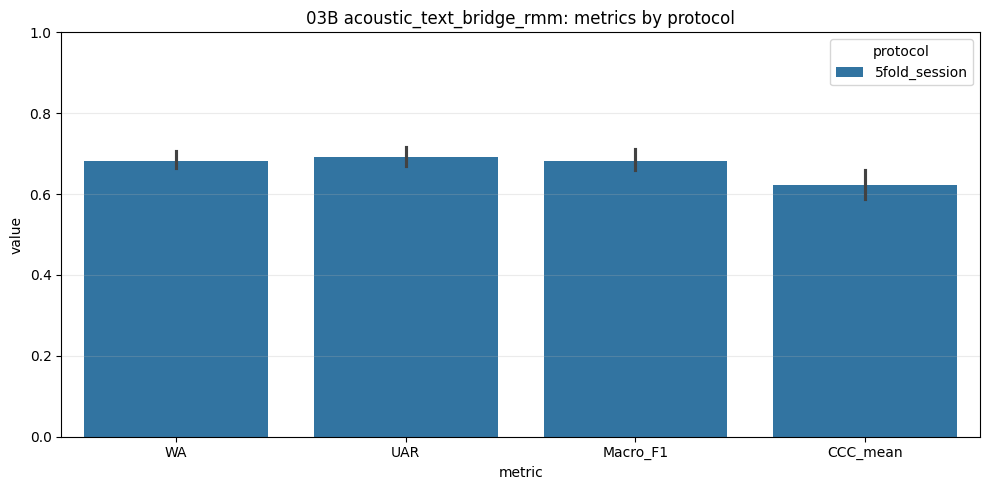

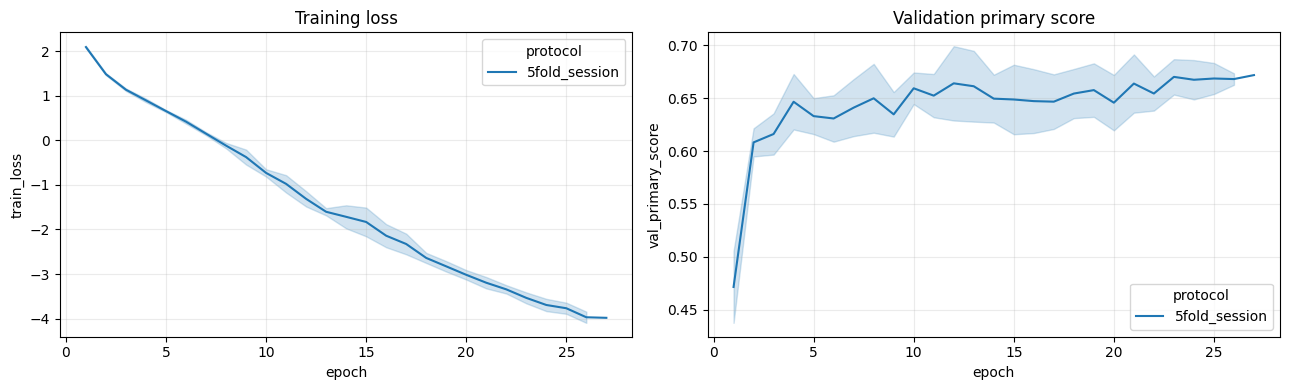

In [17]:
if plt is not None and len(results_df):
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = results_df.melt(id_vars=["protocol", "fold"], value_vars=["WA", "UAR", "Macro_F1", "CCC_mean"], var_name="metric", value_name="value")
    sns.barplot(data=plot_df, x="metric", y="value", hue="protocol", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title(f"03B {FUSION_MODE}: metrics by protocol")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"03B_{FUSION_MODE}_metric_summary.png", dpi=180)
    plt.show()

    hist_files = sorted(REPORT_DIR.glob(f"*_{FUSION_MODE}_history.csv"))
    if hist_files:
        hist = pd.concat([pd.read_csv(p) for p in hist_files], ignore_index=True)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        sns.lineplot(data=hist, x="epoch", y="train_loss", hue="protocol", estimator="mean", errorbar="sd", ax=axes[0])
        axes[0].set_title("Training loss")
        sns.lineplot(data=hist, x="epoch", y="val_primary_score", hue="protocol", estimator="mean", errorbar="sd", ax=axes[1])
        axes[1].set_title("Validation primary score")
        for axis in axes:
            axis.grid(alpha=0.25)
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / f"03B_{FUSION_MODE}_training_curves.png", dpi=180)
        plt.show()

In [18]:
report_md = REPORT_DIR / f"03B_{FUSION_MODE}_report.md"
with report_md.open("w", encoding="utf-8") as f:
    f.write("# 03B Acoustic + Transcript Bridge Fusion Report\n\n")
    f.write("## Config\n\n")
    for k, v in config.items():
        f.write(f"- `{k}`: `{v}`\n")
    f.write("\n## Summary\n\n")
    f.write(summary_df.to_markdown(index=False))
    f.write("\n\n## Ablation / Reference\n\n")
    f.write(reference_df.to_markdown(index=False))
    f.write("\n\n## Interpretation Guide\n\n")
    f.write("- So sánh `acoustic_only` với `acoustic_text_bridge_rmm` để kiểm tra transcript có bổ sung không.\n")
    f.write("- So sánh `acoustic_text_concat` với `acoustic_text_bridge` để kiểm tra bridge-token fusion có tốt hơn nối vector không.\n")
    f.write("- So sánh `acoustic_text_bridge` với `acoustic_text_bridge_rmm` để kiểm tra RMM có làm model cân bằng modality hơn không.\n")

with (REPORT_DIR / f"03B_{FUSION_MODE}_config.json").open("w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

zip_path = OUTPUT_DIR / f"03B_{FUSION_MODE}_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for folder in [REPORT_DIR, FIGURE_DIR, MODEL_DIR, FUSION_DIR]:
        for p in folder.rglob("*"):
            if p.is_file():
                z.write(p, p.relative_to(OUTPUT_DIR))
print("Report:", report_md)
print("Zip:", zip_path)

Report: /kaggle/working/output_03b_advanced_loss_acoustic_protocol/reports/03B_acoustic_text_bridge_rmm_report.md
Zip: /kaggle/working/output_03b_advanced_loss_acoustic_protocol/03B_acoustic_text_bridge_rmm_outputs.zip


In [ ]:
import time
from datetime import timedelta

RUN_HOURS = 3
TOTAL_SECONDS = RUN_HOURS * 60 * 60

start_time = time.time()

print("🚀 Bắt đầu chạy trong 3 tiếng...")

try:
    for hour in range(1, RUN_HOURS + 1):
        time.sleep(60 * 60)  # Chờ 1 tiếng

        elapsed = int(time.time() - start_time)
        remaining = max(0, TOTAL_SECONDS - elapsed)

        print(
            f"⏱ Đã chạy: {timedelta(seconds=elapsed)}"
            f" | Còn lại: {timedelta(seconds=remaining)}"
        )

except KeyboardInterrupt:
    print("\n⛔ Đã dừng thủ công.")

print("✅ Hoàn thành 3 tiếng.")

🚀 Bắt đầu chạy trong 3 tiếng...
⏱ Đã chạy: 1:00:00 | Còn lại: 2:00:00
